In [1]:
import random, os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"
OUTPUT_DIR       = "/kaggle/working/"
MODEL_NAME       = "xlm-roberta-base"  
MAX_LEN          = 128
BATCH_SIZE       = 32
EPOCHS           = 5
LR               = 2e-5
ALPHA            = 0.3   # weight for hate loss
BETA             = 0.3   # weight for sarcasm loss
GAMMA            = 0.4   # weight for 3-class loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
print(f"Device: {device}")
print(f"Model : {MODEL_NAME}")


en_train = pd.read_csv(f"{PREPROCESSED_DIR}/en_train.csv")
en_val   = pd.read_csv(f"{PREPROCESSED_DIR}/en_val.csv")
en_test  = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")
bn_train = pd.read_csv(f"{PREPROCESSED_DIR}/bn_train.csv")
bn_val   = pd.read_csv(f"{PREPROCESSED_DIR}/bn_val.csv")
bn_test  = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")

for df in [en_train, en_val, en_test, bn_train, bn_val, bn_test]:
    df['text_clean'] = df['text_clean'].fillna('')

def add_aux_labels(df, label_col):
    df['is_hateful']   = (df[label_col] == 1).astype(int)
    df['is_sarcastic'] = (df[label_col] == 2).astype(int)
    return df

en_train = add_aux_labels(en_train, 'class')
en_val   = add_aux_labels(en_val,   'class')
en_test  = add_aux_labels(en_test,  'class')
bn_train = add_aux_labels(bn_train, 'label')
bn_val   = add_aux_labels(bn_val,   'label')
bn_test  = add_aux_labels(bn_test,  'label')

print(f"English  — Train: {len(en_train):,}  Val: {len(en_val):,}  Test: {len(en_test):,}")
print(f"Bangla   — Train: {len(bn_train):,}  Val: {len(bn_val):,}  Test: {len(bn_test):,}")
print(f"\nEnglish aux label sample:\n{en_train[['class','is_hateful','is_sarcastic']].head(6)}")

Device: cuda
Model : xlm-roberta-base
English  — Train: 83,455  Val: 10,432  Test: 10,432
Bangla   — Train: 67,009  Val: 8,376  Test: 8,377

English aux label sample:
   class  is_hateful  is_sarcastic
0      1           1             0
1      0           0             0
2      0           0             0
3      1           1             0
4      0           0             0
5      2           0             1


In [2]:
class DualHeadDataset(Dataset):
    def __init__(self, texts, labels_3class, labels_hate, labels_sarc, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels_3class = torch.tensor(labels_3class, dtype=torch.long)
        self.labels_hate   = torch.tensor(labels_hate,   dtype=torch.float)
        self.labels_sarc   = torch.tensor(labels_sarc,   dtype=torch.float)

    def __len__(self):
        return len(self.labels_3class)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels_3class'] = self.labels_3class[idx]
        item['labels_hate']   = self.labels_hate[idx]
        item['labels_sarc']   = self.labels_sarc[idx]
        return item


# ============================================================
# Shared XLM-RoBERTa Dual-Head Model
# ============================================================
class SharedDualHeadModel(nn.Module):
    def __init__(self, model_name, num_classes=3, dropout=0.3):
        super().__init__()

        # Shared encoder
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size   

        self.dropout = nn.Dropout(dropout)

        # Hate head  
        self.hate_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)        
        )

        # Sarcasm head  
        self.sarcasm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)        
        )

        # Fusion MLP — takes CLS + hate_hidden + sarcasm_hidden
        self.fusion_mlp = nn.Sequential(
            nn.Linear(hidden_size + 256 + 256, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)  
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Get shared encoder output
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls_output = self.dropout(outputs.last_hidden_state[:, 0, :])  

        # Hate head — extract penultimate hidden state
        hate_hidden = F.relu(self.hate_head[0](cls_output))   
        hate_hidden = self.dropout(hate_hidden)
        hate_logit  = self.hate_head[3](hate_hidden)           

        # Sarcasm head — extract penultimate hidden state
        sarc_hidden = F.relu(self.sarcasm_head[0](cls_output)) 
        sarc_hidden = self.dropout(sarc_hidden)
        sarc_logit  = self.sarcasm_head[3](sarc_hidden)        

        # Fusion: concatenate CLS + hate_hidden + sarc_hidden
        fused = torch.cat([cls_output, hate_hidden, sarc_hidden], dim=1)

        # Final 3-class prediction
        logits_3class = self.fusion_mlp(fused)

        return logits_3class, hate_logit.squeeze(-1), sarc_logit.squeeze(-1)

In [3]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion_3class = nn.CrossEntropyLoss()
    criterion_binary = nn.BCEWithLogitsLoss()

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        labels_3class  = batch['labels_3class'].to(device)
        labels_hate    = batch['labels_hate'].to(device)
        labels_sarc    = batch['labels_sarc'].to(device)

        optimizer.zero_grad()

        logits_3class, hate_logit, sarc_logit = model(
            input_ids, attention_mask, token_type_ids
        )

        loss_3class = criterion_3class(logits_3class, labels_3class)
        loss_hate   = criterion_binary(hate_logit, labels_hate)
        loss_sarc   = criterion_binary(sarc_logit, labels_sarc)

        # Combined multi-task loss
        loss = ALPHA * loss_hate + BETA * loss_sarc + GAMMA * loss_3class

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device, return_preds=False):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch.get('token_type_ids', None)
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            logits_3class, _, _ = model(input_ids, attention_mask, token_type_ids)
            preds = logits_3class.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels_3class'].numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    if return_preds:
        return f1, np.array(all_preds), np.array(all_labels)
    return f1

In [4]:
# ============================================================
# Run training for one language
# ============================================================
from transformers import get_linear_schedule_with_warmup

def run_training(train_df, val_df, label_col, lang_name,
                 model_name=MODEL_NAME, epochs=EPOCHS,
                 batch_size=BATCH_SIZE, lr=LR):

    print(f"\n{'='*65}")
    print(f"Training Shared Dual-Head XLM-R on {lang_name}")
    print(f"{'='*65}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = DualHeadDataset(
        train_df['text_clean'].values,
        train_df[label_col].values,
        train_df['is_hateful'].values,
        train_df['is_sarcastic'].values,
        tokenizer, MAX_LEN
    )
    val_ds = DualHeadDataset(
        val_df['text_clean'].values,
        val_df[label_col].values,
        val_df['is_hateful'].values,
        val_df['is_sarcastic'].values,
        tokenizer, MAX_LEN
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2, shuffle=False)

    model     = SharedDualHeadModel(model_name).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    total_steps   = len(train_loader) * epochs
    warmup_steps  = total_steps // 10
    scheduler     = get_linear_schedule_with_warmup(
        optimizer, warmup_steps, total_steps
    )

    best_f1, best_state = 0, None
    history = []

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
        val_f1     = evaluate(model, val_loader, device)

        history.append({'epoch': epoch+1, 'loss': train_loss, 'val_f1': val_f1})

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"  Epoch {epoch+1}/{epochs} — Loss: {train_loss:.4f} — Val Macro F1: {val_f1:.4f}")

    # Restore best
    model.load_state_dict(best_state)
    print(f"\nBest Val Macro F1: {best_f1:.4f}")

    # Save model
    save_path = f"{OUTPUT_DIR}dualhead_xlmr_{lang_name}"
    os.makedirs(save_path, exist_ok=True)
    torch.save(model.state_dict(), f"{save_path}/model.pt")
    tokenizer.save_pretrained(save_path)
    print(f"Model saved to {save_path}")

    return model, tokenizer, history


# Train English
model_en, tok_en, hist_en = run_training(
    en_train, en_val, 'class', 'English'
)

# Train Bangla
model_bn, tok_bn, hist_bn = run_training(
    bn_train, bn_val, 'label', 'Bangla'
)


Training Shared Dual-Head XLM-R on English


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 — Loss: 0.4452 — Val Macro F1: 0.8576
  Epoch 2/5 — Loss: 0.2372 — Val Macro F1: 0.8797
  Epoch 3/5 — Loss: 0.1785 — Val Macro F1: 0.8858
  Epoch 4/5 — Loss: 0.1389 — Val Macro F1: 0.8884
  Epoch 5/5 — Loss: 0.1086 — Val Macro F1: 0.8908

Best Val Macro F1: 0.8908
Model saved to /kaggle/working/dualhead_xlmr_English

Training Shared Dual-Head XLM-R on Bangla


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 — Loss: 0.5154 — Val Macro F1: 0.7578
  Epoch 2/5 — Loss: 0.3313 — Val Macro F1: 0.7996
  Epoch 3/5 — Loss: 0.2780 — Val Macro F1: 0.8017
  Epoch 4/5 — Loss: 0.2392 — Val Macro F1: 0.8130
  Epoch 5/5 — Loss: 0.2081 — Val Macro F1: 0.8101

Best Val Macro F1: 0.8130
Model saved to /kaggle/working/dualhead_xlmr_Bangla



DualHead_XLM-R [TEST] — English
Accuracy : 0.8982
Macro F1 : 0.8983
              precision    recall  f1-score   support

 Non-hateful       0.85      0.88      0.87      3470
     Hateful       0.92      0.93      0.92      3486
   Sarcastic       0.93      0.89      0.91      3476

    accuracy                           0.90     10432
   macro avg       0.90      0.90      0.90     10432
weighted avg       0.90      0.90      0.90     10432



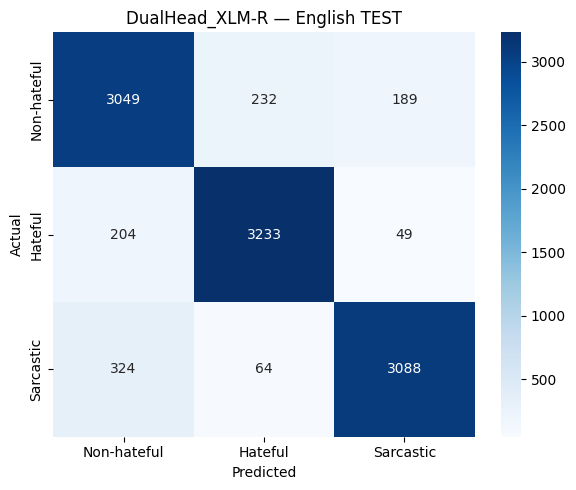


DualHead_XLM-R [TEST] — Bangla
Accuracy : 0.8301
Macro F1 : 0.8151
              precision    recall  f1-score   support

 Non-hateful       0.86      0.82      0.83      4140
     Hateful       0.85      0.93      0.89      2560
   Sarcastic       0.73      0.71      0.72      1677

    accuracy                           0.83      8377
   macro avg       0.81      0.82      0.82      8377
weighted avg       0.83      0.83      0.83      8377



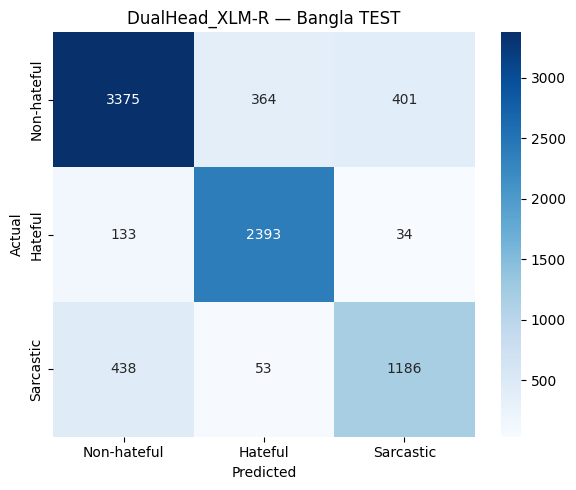

In [5]:
# ============================================================
#   Evaluate on test set
# ============================================================
def test_evaluation(model, tokenizer, test_df, label_col,
                    model_name_str, lang_name):

    test_ds = DualHeadDataset(
        test_df['text_clean'].values,
        test_df[label_col].values,
        test_df['is_hateful'].values,
        test_df['is_sarcastic'].values,
        tokenizer, MAX_LEN
    )
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    f1, preds, labels = evaluate(model, test_loader, device, return_preds=True)

    acc = accuracy_score(labels, preds)
    print(f"\n{'='*60}")
    print(f"{model_name_str} [TEST] — {lang_name}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1:.4f}")
    print(classification_report(labels, preds,
                                target_names=list(CLASS_NAMES.values())))


    from sklearn.metrics import confusion_matrix
    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES.values(),
                yticklabels=CLASS_NAMES.values(), ax=ax)
    ax.set_title(f'{model_name_str} — {lang_name} TEST')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}cm_{model_name_str}_{lang_name}.png", dpi=150)
    plt.show()


    np.save(f"{OUTPUT_DIR}test_preds_{model_name_str}_{lang_name}.npy", preds)
    return acc, f1, preds


acc_en, f1_en, preds_en = test_evaluation(
    model_en, tok_en, en_test, 'class', 'DualHead_XLM-R', 'English'
)
acc_bn, f1_bn, preds_bn = test_evaluation(
    model_bn, tok_bn, bn_test, 'label', 'DualHead_XLM-R', 'Bangla'
)

In [6]:
results = {
    'Model':           ['BERT (baseline)', 'BanglaBERT (baseline)',
                        'DualHead XLM-R', 'DualHead XLM-R'],
    'Language':        ['English', 'Bangla', 'English', 'Bangla'],
    'Test Macro F1':   [0.9029, 0.8200, round(f1_en, 4), round(f1_bn, 4)],
    'Test Accuracy':   [0.9033, 0.8316, round(acc_en, 4), round(acc_bn, 4)],
}

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("PHASE 6A RESULTS vs BASELINES")
print("="*60)
print(df_results.to_string(index=False))
df_results.to_csv(f"{OUTPUT_DIR}phase6a_results.csv", index=False)


en_improvement = round(f1_en - 0.9029, 4)
bn_improvement = round(f1_bn - 0.8200, 4)
print(f"\nImprovement over baseline:")
print(f"  English : {'+' if en_improvement >= 0 else ''}{en_improvement}")
print(f"  Bangla  : {'+' if bn_improvement >= 0 else ''}{bn_improvement}")


PHASE 6A RESULTS vs BASELINES
                Model Language  Test Macro F1  Test Accuracy
      BERT (baseline)  English         0.9029         0.9033
BanglaBERT (baseline)   Bangla         0.8200         0.8316
       DualHead XLM-R  English         0.8983         0.8982
       DualHead XLM-R   Bangla         0.8151         0.8301

Improvement over baseline:
  English : -0.0046
  Bangla  : -0.0049


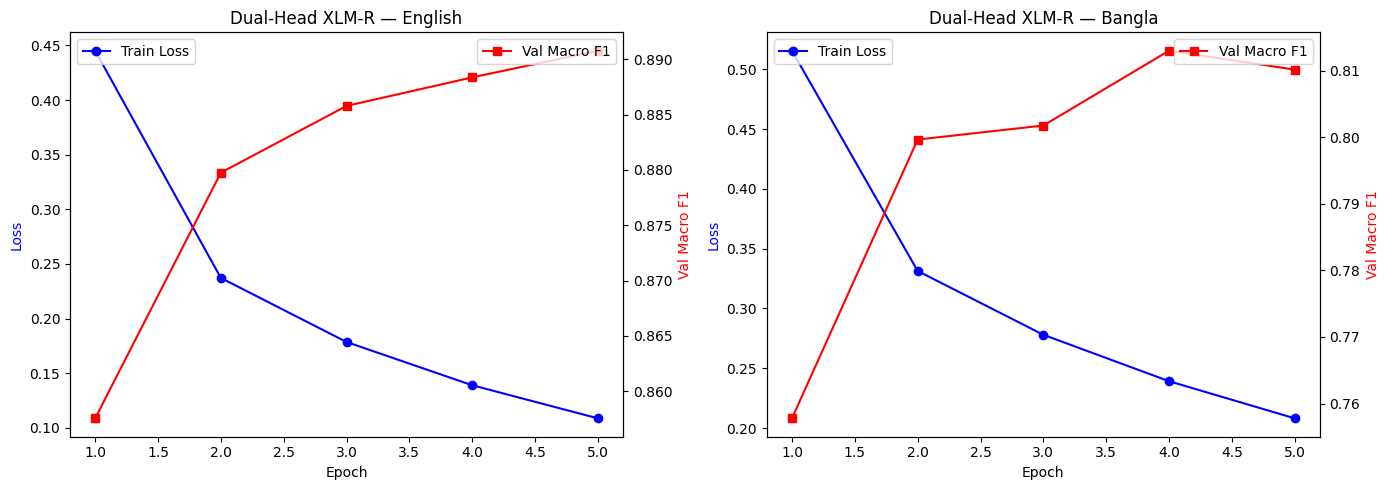

Saved: phase6a_training_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, lang in [(axes[0], hist_en, 'English'),
                        (axes[1], hist_bn, 'Bangla')]:
    epochs_x = [h['epoch'] for h in hist]
    losses   = [h['loss']   for h in hist]
    val_f1s  = [h['val_f1'] for h in hist]

    ax2 = ax.twinx()
    ax.plot(epochs_x, losses,  'b-o', label='Train Loss')
    ax2.plot(epochs_x, val_f1s, 'r-s', label='Val Macro F1')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='blue')
    ax2.set_ylabel('Val Macro F1', color='red')
    ax.set_title(f'Dual-Head XLM-R — {lang}')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}phase6a_training_curves.png", dpi=150)
plt.show()
print("Saved: phase6a_training_curves.png")